# 01 — Data Understanding
## Climate Change: Earth Surface Temperature Analysis

**Người thực hiện:** Lương Minh Kiệt — Project Leader  
**Mục tiêu:** Khảo sát cấu trúc, phạm vi thời gian, kiểu dữ liệu và chất lượng ban đầu của 5 file CSV nhiệt độ bề mặt Trái Đất trước khi xây dựng PostgreSQL pipeline và làm sạch dữ liệu.


## 1. Hiểu bài toán

### 1.1 Bài toán AI

Dự án phân tích sự thay đổi nhiệt độ bề mặt Trái Đất theo thời gian và địa điểm, sau đó xây dựng mô hình Machine Learning để dự đoán nhiệt độ trung bình. Kết quả có thể hỗ trợ nhận biết xu hướng nóng lên, so sánh khu vực và minh họa dự báo trên ứng dụng.

### 1.2 Target và đơn vị quan sát

- **Target chính:** `AverageTemperature` — nhiệt độ trung bình theo tháng, đơn vị °C.
- **Bảng chính cho ML:** `GlobalLandTemperaturesByCountry.csv`.
- **Một dòng của bảng chính:** một quốc gia trong một tháng.
- **Khóa logic dự kiến:** `dt + Country`.

Bảng Country được chọn vì có phạm vi địa lý rộng, số bản ghi đủ lớn, target rõ ràng và kích thước phù hợp để thử nhiều mô hình. Đây là giả định thiết kế ban đầu; hiệu quả của target và feature sẽ được kiểm chứng ở Notebook 04–06.


## 2. Chuẩn bị môi trường

Notebook chỉ đọc dữ liệu raw, không ghi đè hoặc đổi tên cột trong CSV. Các file lớn được quét theo từng chunk để giới hạn RAM.


In [2]:
# Thư viện chuẩn: đường dẫn, cấu trúc CSV, thời gian và cảnh báo.
from pathlib import Path
import csv
import time
import warnings

# Thư viện phân tích dữ liệu và trực quan hóa.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

try:
    from IPython.display import display
except ImportError:
    display = print


### 2.1. Cấu hình hiển thị và hiệu năng

**Mục đích:** đặt các tùy chọn dùng chung sau khi đã import thành công. `pd.set_option()` chỉ thay đổi cách hiển thị; `CHUNK_SIZE` điều khiển lượng dữ liệu đọc mỗi lượt; `COLORS` giữ màu biểu đồ nhất quán.


In [3]:
warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#2563EB', '#0EA5E9', '#14B8A6', '#F59E0B', '#EF4444']
CHUNK_SIZE = 250_000

print('Pandas:', pd.__version__)
print('Chunk size:', f'{CHUNK_SIZE:,}', 'dòng')


Pandas: 3.0.3
Chunk size: 250,000 dòng


### Giải thích hai cell chuẩn bị môi trường

- `Path` giúp xử lý đường dẫn giống nhau trên Windows, macOS và Linux.
- `display()` hiển thị DataFrame đẹp trong Jupyter; nếu chạy bằng Python thường thì tự chuyển sang `print()`.
- Cell import chỉ nạp thư viện; nếu lỗi xảy ra ở đó thì cần sửa môi trường Python trước khi đọc dữ liệu.
- Cell cấu hình chỉ chạy sau khi import thành công và tạo các hằng số dùng cho toàn notebook.
- `CHUNK_SIZE = 250_000` nghĩa là mỗi lần chỉ đưa 250.000 dòng của file lớn vào RAM.
- `pd.set_option()` chỉ thay đổi cách hiển thị, không làm thay đổi dữ liệu.


## 3. Tìm và xác nhận 5 file dữ liệu


In [61]:
# Danh sách kiểm soát: notebook chỉ tiếp tục khi đủ cả năm file.
EXPECTED_FILES = [
    'GlobalLandTemperaturesByCity.csv',
    'GlobalLandTemperaturesByCountry.csv',
    'GlobalLandTemperaturesByMajorCity.csv',
    'GlobalLandTemperaturesByState.csv',
    'GlobalTemperatures.csv',
]


### 3.1. Hàm tìm thư mục dữ liệu

**Đầu vào:** danh sách tên file bắt buộc. **Xử lý:** thử từng vị trí và dùng `all(...)` để xác nhận đủ file. **Đầu ra:** đường dẫn tuyệt đối đầu tiên hợp lệ; nếu không có, hàm báo toàn bộ vị trí đã kiểm tra.


In [62]:
def find_data_directory(expected_files):
    """Tìm thư mục đầu tiên chứa đầy đủ các CSV bắt buộc."""
    candidates = [
        Path('data/raw'), Path('../data/raw'), Path('../../data/raw'),
        Path('upload'), Path('../upload'),
    ]
    checked = []

    for candidate in candidates:
        candidate = candidate.resolve()
        checked.append(str(candidate))
        if candidate.is_dir() and all((candidate / name).is_file() for name in expected_files):
            return candidate

    raise FileNotFoundError(
        'Không tìm thấy đủ 5 file CSV. Hãy đặt file trong data/raw/.\n'
        + 'Đã kiểm tra:\n- ' + '\n- '.join(checked)
    )


### 3.2. Tạo đường dẫn và chọn bảng chính

Cell này thực sự gọi hàm tìm kiếm, tạo dictionary `FILE_PATHS` và chọn bảng Country làm bảng khảo sát chính. Output hợp lệ phải cho thấy đủ 5 file.


In [4]:
catalog_columns = ['file', 'table_role', 'grain', 'candidate_key', 'project_use']
catalog_rows = [
    ('GlobalLandTemperaturesByCountry.csv', 'Main fact table', '1 quốc gia trong 1 tháng', 'dt + Country', 'ML chính, so sánh quốc gia'),
    ('GlobalTemperatures.csv', 'Global summary fact', 'Toàn cầu trong 1 tháng', 'dt', 'Xu hướng toàn cầu, benchmark'),
    ('GlobalLandTemperaturesByState.csv', 'Supporting fact table', '1 bang/tỉnh trong 1 tháng', 'dt + Country + State', 'Phân tích khu vực hành chính'),
    ('GlobalLandTemperaturesByCity.csv', 'Supporting fact table', '1 thành phố–tọa độ trong 1 tháng', 'dt + country + city + latitude + longitude', 'Phân tích chi tiết và dashboard'),
    ('GlobalLandTemperaturesByMajorCity.csv', 'Supporting fact table', '1 thành phố lớn–tọa độ trong 1 tháng', 'dt + Country + City + Latitude + Longitude', 'So sánh các đô thị lớn'),
]

table_catalog = pd.DataFrame(catalog_rows, columns=catalog_columns)
display(table_catalog)


,file,table_role,grain,candidate_key,project_use
0,GlobalLandTemperaturesByCountry.csv,Main fact table,1 quốc gia trong 1 tháng,dt + Country,"ML chính, so sánh quốc gia"
1,GlobalTemperatures.csv,Global summary fact,Toàn cầu trong 1 tháng,dt,"Xu hướng toàn cầu, benchmark"
2,GlobalLandTemperaturesByState.csv,Supporting fact table,1 bang/tỉnh trong 1 tháng,dt + Country + State,Phân tích khu vực hành chính
3,GlobalLandTemperaturesByCity.csv,Supporting fact table,1 thành phố–tọa độ trong 1 tháng,dt + country + city + latitude + longitude,Phân tích chi tiết và dashboard
4,GlobalLandTemperaturesByMajorCity.csv,Supporting fact table,1 thành phố lớn–tọa độ trong 1 tháng,dt + Country + City + Latitude + Longitude,So sánh các đô thị lớn


### Nhận xét

- Country là bảng trung tâm của bài toán ML, nhưng không phải cha vật lý của mọi bảng.
- State và City có thể liên kết phân tích với Country qua `dt + country`.
- Major City là một góc nhìn tập trung vào đô thị lớn, không nên coi là dimension của City.
- Tên City có thể trùng giữa nhiều vị trí, nên candidate key cần thêm Latitude và Longitude thay vì chỉ dùng tên thành phố.
- Global chỉ có `dt`, nên khi join với Country sẽ tạo cùng một chỉ số toàn cầu lặp lại cho mọi quốc gia trong cùng tháng. Điều này chỉ nên làm khi thật sự cần tạo feature benchmark.


## 5. Data Dictionary


In [65]:
data_dictionary = pd.DataFrame([
    ['dt', 'Thời điểm ghi nhận theo tháng', 'Date', 'Month', 'Time / key'],
    ['AverageTemperature / averagetemperature', 'Nhiệt độ trung bình ước tính', 'Numeric', '°C', 'Target / measure'],
    ['AverageTemperatureUncertainty / averagetemperatureuncertainty', 'Độ không chắc chắn của nhiệt độ trung bình', 'Numeric', '°C', 'Quality measure'],
    ['Country / country', 'Tên quốc gia', 'Category', '—', 'Location / key'],
    ['State', 'Bang, tỉnh hoặc khu vực hành chính', 'Category', '—', 'Location / key'],
    ['City / city', 'Tên thành phố', 'Category', '—', 'Location / key'],
    ['Latitude / latitude', 'Vĩ độ, có hậu tố N hoặc S', 'Text coordinate', 'Degree', 'Location'],
    ['Longitude / longitude', 'Kinh độ, có hậu tố E hoặc W', 'Text coordinate', 'Degree', 'Location'],
    ['LandAverageTemperature', 'Nhiệt độ trung bình toàn cầu trên đất liền', 'Numeric', '°C', 'Global target/measure'],
    ['LandAverageTemperatureUncertainty', 'Độ không chắc chắn của nhiệt độ đất liền', 'Numeric', '°C', 'Quality measure'],
    ['LandMaxTemperature', 'Nhiệt độ cực đại trung bình trên đất liền', 'Numeric', '°C', 'Global measure'],
    ['LandMaxTemperatureUncertainty', 'Độ không chắc chắn của nhiệt độ cực đại', 'Numeric', '°C', 'Quality measure'],
    ['LandMinTemperature', 'Nhiệt độ cực tiểu trung bình trên đất liền', 'Numeric', '°C', 'Global measure'],
    ['LandMinTemperatureUncertainty', 'Độ không chắc chắn của nhiệt độ cực tiểu', 'Numeric', '°C', 'Quality measure'],
    ['LandAndOceanAverageTemperature', 'Nhiệt độ trung bình kết hợp đất liền và đại dương', 'Numeric', '°C', 'Global measure'],
    ['LandAndOceanAverageTemperatureUncertainty', 'Độ không chắc chắn của nhiệt độ đất liền và đại dương', 'Numeric', '°C', 'Quality measure'],
], columns=['column', 'meaning', 'expected_group', 'unit', 'role'])
display(data_dictionary)


,column,meaning,expected_group,unit,role
0,dt,Thời điểm ghi nhận theo tháng,Date,Month,Time / key
1,AverageTemperature / averagetemperature,Nhiệt độ trung bình ước tính,Numeric,°C,Target / measure
2,AverageTemperatureUncertainty / averagetemperatureuncertainty,Độ không chắc chắn của nhiệt độ trung bình,Numeric,°C,Quality measure
3,Country / country,Tên quốc gia,Category,—,Location / key
4,State,"Bang, tỉnh hoặc khu vực hành chính",Category,—,Location / key
5,City / city,Tên thành phố,Category,—,Location / key
6,Latitude / latitude,"Vĩ độ, có hậu tố N hoặc S",Text coordinate,Degree,Location
7,Longitude / longitude,"Kinh độ, có hậu tố E hoặc W",Text coordinate,Degree,Location
8,LandAverageTemperature,Nhiệt độ trung bình toàn cầu trên đất liền,Numeric,°C,Global target/measure
9,LandAverageTemperatureUncertainty,Độ không chắc chắn của nhiệt độ đất liền,Numeric,°C,Quality measure


### Nhận xét

Tên cột City đang dùng chữ thường trong file được cung cấp, còn các file khác chủ yếu dùng PascalCase. Notebook 01 chỉ ghi nhận sự khác biệt; việc chuẩn hóa sang `snake_case` sẽ thực hiện ở PostgreSQL/Cleaning và phải có bảng mapping rõ ràng. Latitude/Longitude vẫn là chuỗi vì có ký tự hướng, chưa nên ép trực tiếp sang số.


## 6. Kiểm tra nhanh schema và tính toàn vẹn của từng file


In [66]:
def inspect_file_tail(path, tail_bytes=65_536):
    size_bytes = path.stat().st_size

    with path.open('rb') as file:
        header = file.readline().decode('utf-8-sig', errors='replace').rstrip('\r\n')
        if size_bytes > tail_bytes:
            file.seek(-tail_bytes, 2)
        tail = file.read()

    last_line = tail.decode('utf-8', errors='replace').splitlines()[-1]
    header_fields = len(next(csv.reader([header])))
    last_fields = len(next(csv.reader([last_line])))

    return {
        'file': path.name,
        'file_size_mb': size_bytes / 1024**2,
        'header_fields': header_fields,
        'last_row_fields': last_fields,
        'ends_with_newline': tail.endswith((b'\n', b'\r')),
        'field_count_status': 'OK' if last_fields == header_fields else 'Cần kiểm tra lại bản sao CSV',
    }


### 6.1. Áp dụng kiểm tra cho năm file

Hàm phía trên chỉ định nghĩa quy tắc. Cell này mới thực thi quy tắc cho từng đường dẫn, gom kết quả thành `integrity_df` và hiển thị. Chỉ số `field_count_status` khác `OK` là tín hiệu phải xác minh lại file trước khi tin các thống kê sau.


In [67]:
integrity_df = pd.DataFrame(inspect_file_tail(path) for path in FILE_PATHS.values())
display(integrity_df)


,file,file_size_mb,header_fields,last_row_fields,ends_with_newline,field_count_status
0,GlobalLandTemperaturesByCity.csv,297.8377,7,7,True,OK
1,GlobalLandTemperaturesByCountry.csv,21.6297,4,4,True,OK
2,GlobalLandTemperaturesByMajorCity.csv,13.4834,7,7,True,OK
3,GlobalLandTemperaturesByState.csv,29.3447,5,5,True,OK
4,GlobalTemperatures.csv,0.1963,9,9,True,OK


# PHẦN A — KHẢO SÁT BẢNG CHÍNH (COUNTRY)

Bảng Country được đọc đầy đủ vì kích thước vừa phải. Các file lớn còn lại sẽ được quét theo chunk ở Phần B.


## 7. Đọc bảng chính và xem dữ liệu mẫu


In [5]:
main_raw = pd.read_csv(MAIN_PATH, low_memory=False)
main_df = main_raw.copy()

print('Shape:', main_df.shape)
display(main_df.head())
display(main_df.sample(5, random_state=42))


Shape: (577462, 4)


,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.3840,2.2940,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


,dt,AverageTemperature,AverageTemperatureUncertainty,Country
432136,1967-02-01,-23.7140,0.3150,Russia
237733,1786-11-01,1.7970,5.8730,Hungary
144098,1956-10-01,-20.1800,0.7520,Denmark
312208,1910-08-01,28.5690,0.3880,Macau
58319,1773-10-01,10.7140,1.8610,Belgium


### Giải thích và nhận xét

`head()` giúp kiểm tra thứ tự và định dạng vài dòng đầu; `sample()` lấy ngẫu nhiên để tránh chỉ nhìn một quốc gia đầu file. `random_state=42` giúp lần chạy sau lấy đúng cùng mẫu, thuận tiện khi báo cáo nhóm. `copy()` giữ lại phiên bản raw để so sánh trước/sau chuyển kiểu.


## 8. Kích thước và bộ nhớ


In [6]:
main_memory_bytes = main_df.memory_usage(deep=True).sum()
main_size_summary = pd.DataFrame({
    'metric': ['Rows', 'Columns', 'CSV size (MB)', 'DataFrame memory (MB)'],
    'value': [
        len(main_df),
        main_df.shape[1],
        MAIN_PATH.stat().st_size / 1024**2,
        main_memory_bytes / 1024**2,
    ],
})
display(main_size_summary)

main_df.info(memory_usage='deep')


,metric,value
0,Rows,"577,462.0000"
1,Columns,4.0000
2,CSV size (MB),21.6297
3,DataFrame memory (MB),82.5954


<class 'pandas.DataFrame'>
RangeIndex: 577462 entries, 0 to 577461
Data columns (total 4 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   dt                             577462 non-null  str    
 1   AverageTemperature             544811 non-null  float64
 2   AverageTemperatureUncertainty  545550 non-null  float64
 3   Country                        577462 non-null  str    
dtypes: float64(2), str(2)
memory usage: 82.6 MB


### Giải thích và nhận xét

`memory_usage(deep=True)` tính cả bộ nhớ thật của chuỗi, chính xác hơn mặc định. DataFrame thường chiếm RAM khác dung lượng CSV vì pandas phải tạo object, index và mảng số trong bộ nhớ. `info()` đồng thời cho biết non-null count và dtype của từng cột.


## 9. Cấu trúc, kiểu dữ liệu, số giá trị khác nhau và Unique Ratio


In [7]:
print('Target missing:', f'{main_df["AverageTemperature"].isna().sum():,}')
print('Target missing (%):', f'{main_df["AverageTemperature"].isna().mean() * 100:.2f}%')


Target missing: 32,651
Target missing (%): 5.65%


### Nhận xét

Target gộp nhiều quốc gia và mùa nên phân phối rộng, có thể nhiều đỉnh. Các điểm ngoài whisker boxplot chưa chắc là dữ liệu sai; chúng có thể đại diện cho mùa đông ở vùng rất lạnh hoặc mùa hè ở vùng nóng. Mô hình nên có feature `country`, `year`, `month` và có thể dùng uncertainty làm feature chất lượng.


# PHẦN B — KHẢO SÁT TOÀN BỘ 5 BẢNG

Các helper dưới đây được tách thành nhiều cell: một cell gộp thống kê số, một cell quét file và một cell thực thi. Cách này dễ đọc và dễ kiểm thử hơn một khối code dài.


## 16. Helper 1 — Gộp thống kê số giữa các chunk


In [79]:
def merge_numeric_state(state, series):
    values = series.dropna().astype('float64')
    if values.empty:
        return state

    count_b = len(values)
    mean_b = values.mean()
    m2_b = ((values - mean_b) ** 2).sum()

    if state is None:
        return {
            'count': count_b, 'mean': mean_b, 'm2': m2_b,
            'min': values.min(), 'max': values.max(),
        }

    count_a = state['count']
    total = count_a + count_b
    delta = mean_b - state['mean']
    state['mean'] += delta * count_b / total
    state['m2'] += m2_b + delta**2 * count_a * count_b / total
    state['count'] = total
    state['min'] = min(state['min'], values.min())
    state['max'] = max(state['max'], values.max())
    return state


### Giải thích code khó

Mỗi chunk có count, mean và tổng bình phương sai lệch riêng (`m2`). Công thức dùng `delta` để gộp hai nhóm mà không giữ toàn bộ số liệu trong RAM. Sau cùng `std = sqrt(m2 / (count - 1))`. Cách này ổn định hơn việc cộng `x²` trực tiếp.


## 17. Helper 2 — Quét một file CSV


In [80]:
# Khóa logic dự kiến cho từng grain dữ liệu.
KEY_SPECS = {
    'GlobalTemperatures.csv': ['dt'],
    'GlobalLandTemperaturesByCountry.csv': ['dt', 'Country'],
    'GlobalLandTemperaturesByState.csv': ['dt', 'Country', 'State'],
    'GlobalLandTemperaturesByCity.csv': ['dt', 'country', 'city', 'latitude', 'longitude'],
    'GlobalLandTemperaturesByMajorCity.csv': ['dt', 'Country', 'City', 'Latitude', 'Longitude'],
}


### 17.1. Khởi tạo trạng thái quét

**Đầu vào:** đường dẫn CSV. **Xử lý:** đọc 10.000 dòng mẫu để xác định schema, cột số và dimension. **Đầu ra:** một dictionary chứa toàn bộ bộ đếm rỗng. Hàm này chưa quét toàn bộ file.


In [81]:
def create_scan_state(path):
    """Tạo metadata và bộ đếm trước khi đọc file theo chunk."""
    sample = pd.read_csv(path, nrows=10_000, low_memory=False)
    columns = sample.columns.tolist()
    numeric_columns = sample.select_dtypes(include='number').columns.tolist()
    dimension_columns = [c for c in columns if c.casefold() in {'city', 'country', 'state'}]
    return {
        'sample': sample, 'columns': columns, 'numeric_columns': numeric_columns,
        'dimension_columns': dimension_columns, 'key_columns': KEY_SPECS[path.name],
        'row_count': 0, 'missing': pd.Series(0, index=columns, dtype='int64'),
        'numeric_states': {column: None for column in numeric_columns},
        'dimension_values': {column: set() for column in dimension_columns},
        'unique_dates': set(), 'full_hashes': [], 'key_hashes': [],
        'date_min': None, 'date_max': None, 'invalid_dates': 0,
    }


### 17.2. Cập nhật thông tin ngày

Cell helper này chỉ phụ trách `dt`: parse ngày, đếm giá trị sai, lưu các ngày phân biệt và cập nhật mốc nhỏ nhất/lớn nhất. Tách riêng giúp phần quét chunk không bị trộn với logic thời gian.


In [82]:
def update_date_state(state, date_series):
    """Cập nhật kiểm tra ngày từ một Series của chunk hiện tại."""
    parsed = pd.to_datetime(date_series, errors='coerce')
    state['invalid_dates'] += int(parsed.isna().sum() - date_series.isna().sum())
    state['unique_dates'].update(parsed.dropna().unique())

    current_min, current_max = parsed.min(), parsed.max()
    if pd.notna(current_min) and (state['date_min'] is None or current_min < state['date_min']):
        state['date_min'] = current_min
    if pd.notna(current_max) and (state['date_max'] is None or current_max > state['date_max']):
        state['date_max'] = current_max


### 17.3. Cập nhật trạng thái từ một chunk

Mỗi lần hàm nhận tối đa `CHUNK_SIZE` dòng. Nó cập nhật row count, missing, hai loại hash, thông tin ngày, thống kê số và giá trị dimension; không tạo bản sao toàn bộ file trong RAM.


In [83]:
def update_scan_state(state, chunk):
    """Gộp thông tin của một chunk vào trạng thái toàn file."""
    state['row_count'] += len(chunk)
    state['missing'] = state['missing'].add(chunk.isna().sum(), fill_value=0).astype('int64')
    state['full_hashes'].append(pd.util.hash_pandas_object(chunk, index=False).to_numpy('uint64'))
    key_data = chunk[state['key_columns']]
    state['key_hashes'].append(pd.util.hash_pandas_object(key_data, index=False).to_numpy('uint64'))

    update_date_state(state, chunk['dt'])
    for column in state['numeric_columns']:
        state['numeric_states'][column] = merge_numeric_state(
            state['numeric_states'][column], chunk[column]
        )
    for column in state['dimension_columns']:
        state['dimension_values'][column].update(chunk[column].dropna().astype(str).unique())


### 17.4. Hoàn thiện thống kê số

Các trạng thái `count/mean/m2/min/max` được đổi thành bảng `numeric_summary`. Độ lệch chuẩn dùng mẫu số `count - 1`, giống mặc định của pandas.


In [84]:
def build_numeric_summary(numeric_states):
    """Chuyển trạng thái tích lũy thành thống kê dễ hiển thị."""
    numeric_summary = []
    for column, column_state in numeric_states.items():
        if column_state is None:
            continue
        std = np.sqrt(column_state['m2'] / (column_state['count'] - 1)) if column_state['count'] > 1 else 0
        numeric_summary.append({
            'column': column, 'count': column_state['count'], 'mean': column_state['mean'],
            'std': std, 'min': column_state['min'], 'max': column_state['max'],
        })
    return numeric_summary


### 17.5. Đóng gói kết quả của một file

Sau chunk cuối, hash được ghép để đếm duplicate, memory được ước tính từ mẫu và mọi chỉ số được đóng gói vào một dictionary thống nhất. Đây là cấu trúc mà các mục 19–25 sử dụng.


In [85]:
def finalize_scan_result(path, state):
    """Tính chỉ số cuối và trả về kết quả của một CSV."""
    full_hashes = np.concatenate(state['full_hashes'])
    key_hashes = np.concatenate(state['key_hashes'])
    full_duplicates = int(len(full_hashes) - len(np.unique(full_hashes)))
    key_duplicates = int(len(key_hashes) - len(np.unique(key_hashes)))
    sample = state['sample']
    bytes_per_row = sample.memory_usage(deep=True).sum() / max(len(sample), 1)

    return {
        'file': path.name, 'rows': state['row_count'], 'columns': len(state['columns']),
        'column_names': state['columns'], 'dtypes': sample.dtypes.astype(str).to_dict(),
        'date_min': state['date_min'], 'date_max': state['date_max'],
        'invalid_dates': state['invalid_dates'], 'distinct_dates': state['unique_dates'],
        'missing': state['missing'].to_dict(),
        'full_duplicates': full_duplicates, 'key_duplicates': key_duplicates,
        'dimension_values': state['dimension_values'],
        'numeric_summary': build_numeric_summary(state['numeric_states']),
        'estimated_memory_mb': bytes_per_row * state['row_count'] / 1024**2,
    }


### 17.6. Hàm điều phối

Hàm chính giờ chỉ còn ba bước: khởi tạo, cập nhật từng chunk và hoàn thiện kết quả. Người đọc có thể hiểu luồng tổng thể mà không phải đọc lại các công thức chi tiết.


In [86]:
def scan_csv(path, chunk_size=250_000):
    """Quét toàn bộ CSV theo chunk và trả về kết quả tổng hợp."""
    state = create_scan_state(path)
    for chunk in pd.read_csv(path, chunksize=chunk_size, low_memory=False):
        update_scan_state(state, chunk)
    return finalize_scan_result(path, state)


### Giải thích code khó

- `c.casefold()` nhận ra cả `Country` và `country` nhưng không đổi tên cột raw.
- Row hash biến mỗi dòng thành số 64-bit để đếm duplicate toàn file với ít RAM hơn. Key hash làm tương tự nhưng chỉ trên các cột khóa logic.
- `np.concatenate()` ghép các hash của từng chunk; `np.unique()` đếm số hash khác nhau.
- Memory của bảng phụ là ước tính từ 10.000 dòng mẫu, vì đọc toàn bộ file City chỉ để đo RAM là không cần thiết.


## 18. Thực thi quét 5 file


In [87]:
scan_results = []
scan_start = time.perf_counter()

for name, path in FILE_PATHS.items():
    start = time.perf_counter()
    result = scan_csv(path, CHUNK_SIZE)
    scan_results.append(result)
    print(f'{name}: {result["rows"]:,} dòng — {time.perf_counter() - start:.2f} giây')

print(f'Tổng thời gian: {time.perf_counter() - scan_start:.2f} giây')


GlobalLandTemperaturesByCity.csv: 5,010,113 dòng — 16.24 giây
GlobalLandTemperaturesByCountry.csv: 577,462 dòng — 1.34 giây
GlobalLandTemperaturesByMajorCity.csv: 239,177 dòng — 0.58 giây
GlobalLandTemperaturesByState.csv: 645,675 dòng — 1.70 giây
GlobalTemperatures.csv: 3,192 dòng — 0.03 giây
Tổng thời gian: 19.90 giây


## 19. Tổng quan bảng phụ và toàn bộ dataset


In [8]:
overview_df = pd.DataFrame([{
    'file': result['file'],
    'rows': result['rows'],
    'columns': result['columns'],
    'estimated_memory_mb': result['estimated_memory_mb'],
    'date_min': result['date_min'],
    'date_max': result['date_max'],
    'invalid_dates': result['invalid_dates'],
    'full_duplicates': result['full_duplicates'],
    'key_duplicates': result['key_duplicates'],
} for result in scan_results])
display(overview_df)


,file,rows,columns,estimated_memory_mb,date_min,date_max,invalid_dates,full_duplicates,key_duplicates
0,GlobalLandTemperaturesByCity.csv,5010113,7,"1,716.9557",1863-01-01,2013-09-01,0,0,0
1,GlobalLandTemperaturesByCountry.csv,577462,4,85.2417,1743-11-01,2013-09-01,0,0,0
2,GlobalLandTemperaturesByMajorCity.csv,239177,7,78.1487,1743-11-01,2013-09-01,0,0,0
3,GlobalLandTemperaturesByState.csv,645675,5,130.2918,1743-11-01,2013-09-01,0,0,0
4,GlobalTemperatures.csv,3192,9,0.3989,1750-01-01,2015-12-01,0,0,0


### Nhận xét

Số dòng khác nhau mạnh vì grain khác nhau: một tháng có một dòng Global nhưng có thể có hàng nghìn dòng City. Key duplicate quan trọng hơn full duplicate vì hai dòng có cùng tháng và địa điểm nhưng số đo khác nhau vẫn có thể gây lỗi khi thiết kế primary key PostgreSQL.


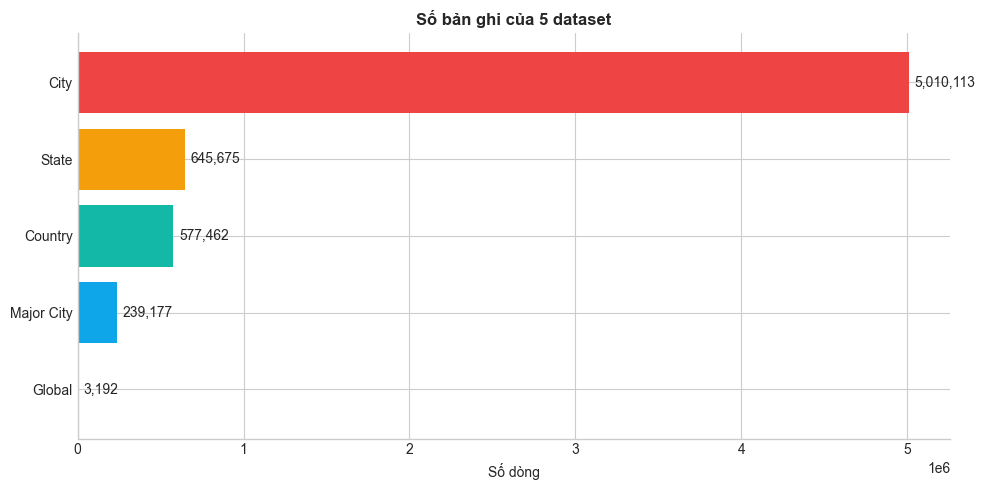

In [9]:
plot_df = overview_df.copy()
plot_df['dataset'] = plot_df['file'].map(SHORT_NAMES)
plot_df = plot_df.sort_values('rows')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(plot_df['dataset'], plot_df['rows'], color=COLORS)
ax.bar_label(bars, labels=[f'{value:,.0f}' for value in plot_df['rows']], padding=4)
ax.set_title('Số bản ghi của 5 dataset', weight='bold')
ax.set_xlabel('Số dòng')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### Nhận xét biểu đồ

### Biểu đồ 2 — Phạm vi thời gian

Mỗi đoạn thẳng biểu diễn từ ngày nhỏ nhất đến ngày lớn nhất của một dataset. Biểu đồ này giúp nhìn ra ngay các file không cùng mốc bắt đầu/kết thúc.


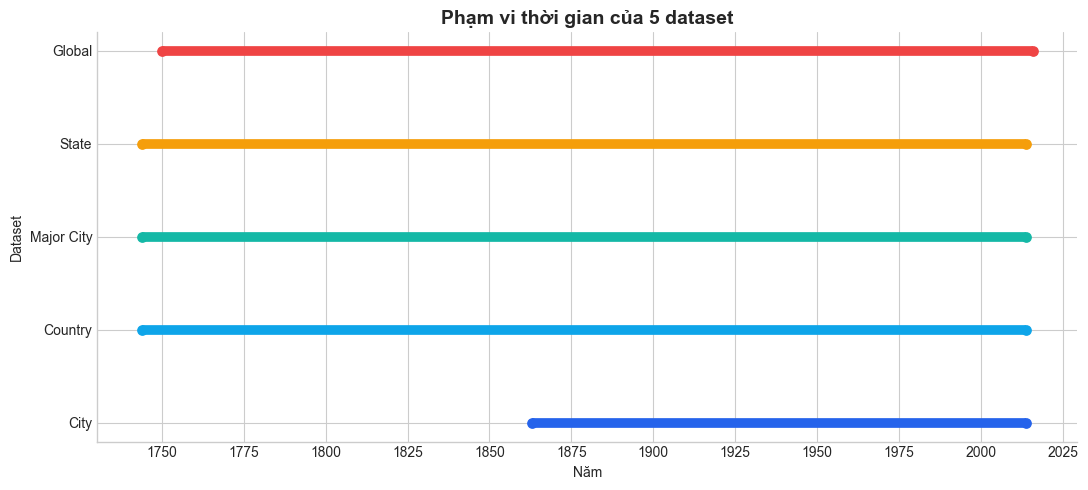

In [10]:
timeline_df = overview_df.copy()
timeline_df['dataset'] = timeline_df['file'].map(SHORT_NAMES)
timeline_df['date_min'] = pd.to_datetime(timeline_df['date_min'])
timeline_df['date_max'] = pd.to_datetime(timeline_df['date_max'])

fig, ax = plt.subplots(figsize=(11, 5))
for position, row in timeline_df.reset_index(drop=True).iterrows():
    ax.hlines(position, row['date_min'], row['date_max'], color=CHART_COLORS[position], linewidth=7)
    ax.scatter([row['date_min'], row['date_max']], [position, position], color=CHART_COLORS[position], s=45)

ax.set_yticks(range(len(timeline_df)), timeline_df['dataset'])
ax.xaxis.set_major_locator(mdates.YearLocator(25))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Phạm vi thời gian của 5 dataset', fontsize=14, weight='bold')
ax.set_xlabel('Năm')
ax.set_ylabel('Dataset')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


**Nhận xét:** Country, State và Major City có dữ liệu sớm nhất từ 1743; City chỉ bắt đầu từ 1863; Global kéo dài đến 2015. Không cần cắt tất cả về cùng khoảng năm ở Data Understanding. Chỉ chọn giai đoạn giao nhau khi một phân tích sau này thực sự cần so sánh trực tiếp.


## 8. Kiểm tra dữ liệu thiếu

Không xử lý giá trị thiếu ở notebook này. Mục đích là đo lường và cung cấp bằng chứng cho việc xây dựng quy tắc làm sạch ở `03_data_cleaning.ipynb`. Tỷ lệ thiếu cần được đọc cùng với phạm vi thời gian: một số biến toàn cầu chỉ bắt đầu được ghi nhận muộn hơn nên thiếu có tính hệ thống, không hẳn là lỗi ngẫu nhiên.


In [11]:
missing_rows = []
for result in scan_results:
    for column, count in result['missing'].items():
        missing_rows.append({
            'file': result['file'], 'column': column,
            'missing_count': count,
            'missing_percent': count / result['rows'] * 100,
        })

missing_all_df = pd.DataFrame(missing_rows)
missing_nonzero = missing_all_df.query('missing_count > 0').sort_values('missing_percent', ascending=False)
display(missing_nonzero)


,file,column,missing_count,missing_percent
29,GlobalTemperatures.csv,LandMinTemperatureUncertainty,1200,37.5940
31,GlobalTemperatures.csv,LandAndOceanAverageTemperatureUncertainty,1200,37.5940
30,GlobalTemperatures.csv,LandAndOceanAverageTemperature,1200,37.5940
28,GlobalTemperatures.csv,LandMinTemperature,1200,37.5940
27,GlobalTemperatures.csv,LandMaxTemperatureUncertainty,1200,37.5940
26,GlobalTemperatures.csv,LandMaxTemperature,1200,37.5940
8,GlobalLandTemperaturesByCountry.csv,AverageTemperature,32651,5.6542
9,GlobalLandTemperaturesByCountry.csv,AverageTemperatureUncertainty,31912,5.5263
12,GlobalLandTemperaturesByMajorCity.csv,AverageTemperature,11002,4.5999
13,GlobalLandTemperaturesByMajorCity.csv,AverageTemperatureUncertainty,11002,4.5999


### 20.1. Vẽ các tỷ lệ missing cao nhất

Cell bảng phía trên giữ toàn bộ cặp file–cột có missing. Cell biểu đồ chỉ lấy 12 tỷ lệ cao nhất để nhãn đọc được; đây là bước trình bày, không phải thao tác xóa hoặc điền dữ liệu.


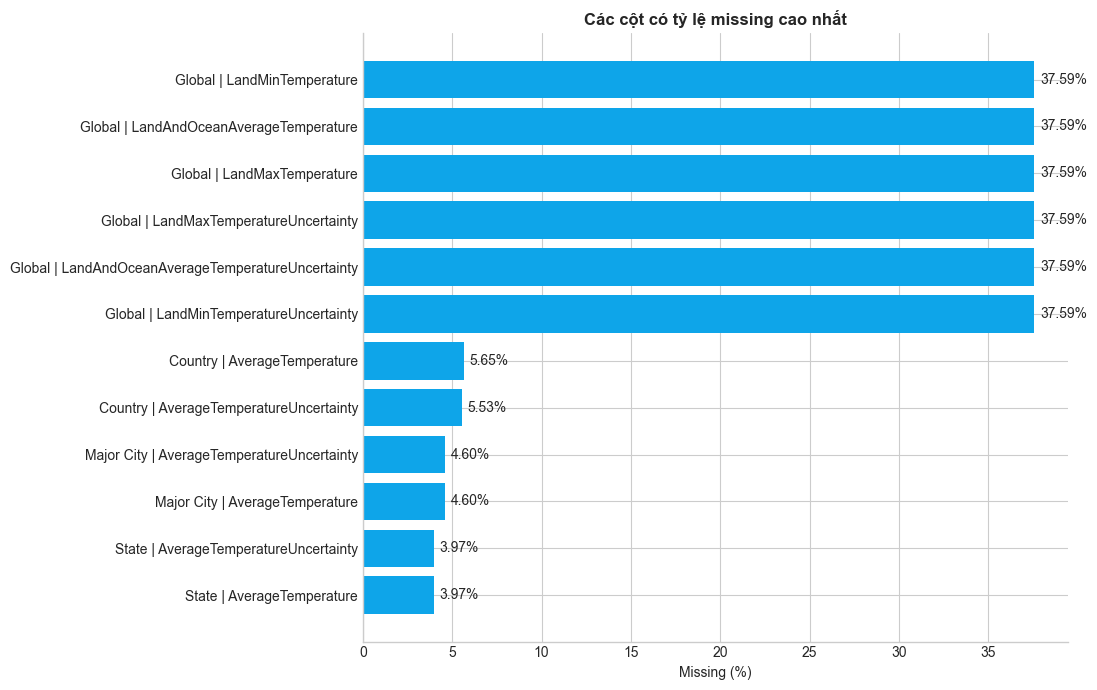

In [12]:
top_missing = missing_nonzero.nlargest(12, 'missing_percent').copy()
top_missing['label'] = top_missing['file'].map(SHORT_NAMES) + ' | ' + top_missing['column']
top_missing = top_missing.sort_values('missing_percent')

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_missing['label'], top_missing['missing_percent'], color='#0EA5E9')
ax.bar_label(bars, labels=[f'{value:.2f}%' for value in top_missing['missing_percent']], padding=4)
ax.set_title('Các cột có tỷ lệ missing cao nhất', weight='bold')
ax.set_xlabel('Missing (%)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### Nhận xét missing

**Giải thích code:** `nlargest(12, 'missing_percent')` chọn 12 tỷ lệ lớn nhất; `copy()` tạo bản sao để thêm cột nhãn mà không sửa `missing_only_df`; `bar_label()` in trực tiếp tỷ lệ phần trăm lên từng cột.


## 9. Kiểm tra dòng trùng

Dòng trùng được xét trên toàn bộ giá trị của một bản ghi. Kết quả 0 không có nghĩa là mỗi khóa logic `(dt, địa điểm)` đều duy nhất; kiểm tra khóa nghiệp vụ nên được thực hiện thêm khi thiết kế bảng PostgreSQL.


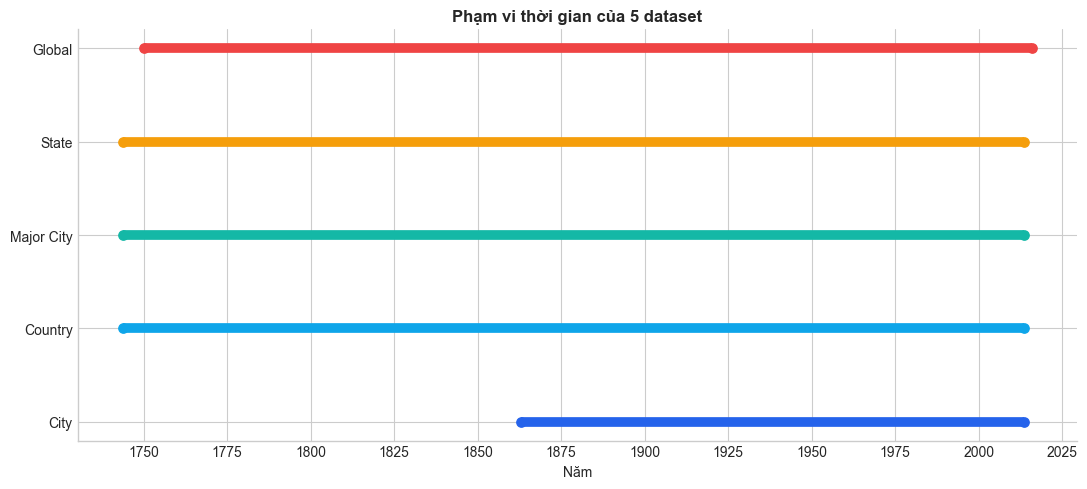

In [13]:
duplicate_df = overview_df[['file', 'rows', 'duplicate_rows']].copy()
duplicate_df['duplicate_percent'] = duplicate_df['duplicate_rows'] / duplicate_df['rows'] * 100
display(duplicate_df)


## 10. Thống kê mô tả các cột số

`mean` là giá trị trung bình, `std` là độ lệch chuẩn, còn `min` và `max` cho biết biên quan sát. Giá trị cực trị ở đây chỉ là dấu hiệu cần khảo sát; chưa được kết luận là outlier và chưa bị loại bỏ.


In [14]:
numeric_rows = []
for result in scan_results:
    for row in result['numeric_summary']:
        numeric_rows.append({'file': result['file'], **row})

numeric_summary_df = pd.DataFrame(numeric_rows)
display(numeric_summary_df)


,file,column,count,mean,std,min,max
0,GlobalLandTemperaturesByCity.csv,averagetemperature,5010113,17.3489,10.2452,-42.7040,38.1820
1,GlobalLandTemperaturesByCity.csv,averagetemperatureuncertainty,4962744,0.5868,0.4528,0.0340,12.6940
2,GlobalLandTemperaturesByCountry.csv,AverageTemperature,544811,17.1934,10.9540,-37.6580,38.8420
3,GlobalLandTemperaturesByCountry.csv,AverageTemperatureUncertainty,545550,1.0191,1.2019,0.0520,15.0030
4,GlobalLandTemperaturesByMajorCity.csv,AverageTemperature,228175,18.1260,10.0248,-26.7720,38.2830
5,GlobalLandTemperaturesByMajorCity.csv,AverageTemperatureUncertainty,228175,0.9693,0.9796,0.0400,14.0370
6,GlobalLandTemperaturesByState.csv,AverageTemperature,620027,8.9931,13.7722,-45.3890,36.3390
7,GlobalLandTemperaturesByState.csv,AverageTemperatureUncertainty,620027,1.2876,1.3604,0.0360,12.6460
8,GlobalTemperatures.csv,LandAverageTemperature,3180,8.3747,4.3813,-2.0800,19.0210
9,GlobalTemperatures.csv,LandAverageTemperatureUncertainty,3180,0.9385,1.0964,0.0340,7.8800


### Biểu đồ 4 — Khoảng nhiệt độ quan sát

Đoạn thẳng biểu diễn min–max, còn dấu chấm biểu diễn mean của cột nhiệt độ trung bình chính trong mỗi dataset. Biểu đồ dùng để phát hiện phạm vi đáng chú ý, chưa dùng để kết luận outlier.


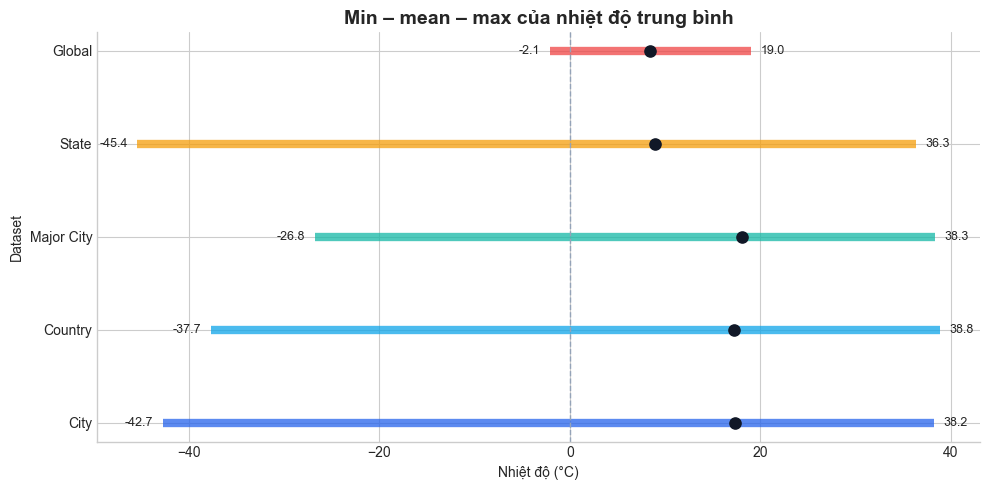

In [15]:
main_temperature_names = {'averagetemperature', 'landaveragetemperature'}
temperature_range = numeric_summary_df[
    numeric_summary_df['column'].str.casefold().isin(main_temperature_names)
].copy()
temperature_range['dataset'] = temperature_range['file'].map(SHORT_NAMES)
temperature_range = temperature_range.reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
for position, row in temperature_range.iterrows():
    color = CHART_COLORS[position]
    ax.hlines(position, row['min'], row['max'], color=color, linewidth=6, alpha=0.75)
    ax.scatter(row['mean'], position, color='#111827', s=65, zorder=3)
    ax.text(row['min'] - 1, position, f'{row["min"]:.1f}', ha='right', va='center', fontsize=9)
    ax.text(row['max'] + 1, position, f'{row["max"]:.1f}', ha='left', va='center', fontsize=9)

ax.set_yticks(range(len(temperature_range)), temperature_range['dataset'])
ax.axvline(0, color='#94A3B8', linewidth=1, linestyle='--')
ax.set_title('Min – mean – max của nhiệt độ trung bình', fontsize=14, weight='bold')
ax.set_xlabel('Nhiệt độ (°C)')
ax.set_ylabel('Dataset')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### Nhận xét thời gian

Các file không cùng mốc bắt đầu và kết thúc. Đây không phải lỗi làm sạch. Mỗi bảng nên giữ đầy đủ lịch sử; chỉ dùng giai đoạn giao nhau khi một phép so sánh hoặc join cụ thể yêu cầu. Nếu cắt tất cả về cùng năm quá sớm, dự án sẽ mất giá trị phân tích dài hạn.


## 21. Kiểm tra quan hệ giữa các bảng

Số lượng giá trị phân biệt giúp kiểm tra độ phủ địa lý và dự kiến kích thước các bảng dimension trong PostgreSQL. Nếu một file bị cắt, kết quả đếm có thể bị sai; với các file hiện tại đều có `tail_status = OK`, số liệu Major City có thể được sử dụng cho các bước tiếp theo.


In [16]:
relationship_df = pd.DataFrame(relationship_rows)
display(relationship_df)


,table,distinct_countries,countries_found_in_country_table,country_match_percent,distinct_dates,dates_found_in_global_table,date_match_percent
0,GlobalLandTemperaturesByState.csv,7,7,100.0000,3239,3165,97.7153
1,GlobalLandTemperaturesByCity.csv,80,80,100.0000,1809,1809,100.0000
2,GlobalLandTemperaturesByMajorCity.csv,49,49,100.0000,3239,3165,97.7153


### Giải thích và nhận xét

Phép `&` giữa hai set lấy phần giao nhau. Tỷ lệ match thấp có thể do khác cách viết tên quốc gia hoặc do bảng chỉ bao phủ một phần thế giới. Tỷ lệ ngày không đạt 100% có thể do phạm vi lịch sử khác nhau, không đồng nghĩa foreign key sai.

Quan hệ phân tích dự kiến:

- Country → State: 1–N theo `Country + dt`.
- Country → City: 1–N theo `Country + dt`.
- City ↔ Major City: ưu tiên đối chiếu theo `Country + City + Latitude + Longitude + dt`; Major City không bắt buộc là subset hoàn hảo.
- Global → Country: 1–N theo `dt`.

Nếu join Country với City theo `Country + dt`, một dòng Country sẽ lặp cho nhiều City. Đây là hành vi 1–N đúng, nhưng không được dùng kết quả đó làm flat table ML cấp Country nếu chưa aggregate City về một dòng cho mỗi `Country + dt`.


## 22. Đánh giá sơ bộ các nhóm cột quan trọng


In [17]:
initial_feature_assessment = pd.DataFrame([
    ['AverageTemperature', 'Target', 'Giữ làm biến cần dự đoán; xử lý missing có kiểm soát'],
    ['AverageTemperatureUncertainty', 'Quality / numeric feature', 'Kiểm tra missing và phân phối theo thời gian'],
    ['dt', 'Time key', 'Chuyển datetime; tạo year, month, decade ở Notebook 05'],
    ['Country', 'Category / location key', 'Chuẩn hóa tên; encoding trong pipeline ML'],
    ['Latitude, Longitude', 'Geospatial feature', 'Đổi N/S/E/W thành số có dấu nếu dùng City'],
    ['Global temperature measures', 'External benchmark feature', 'Chỉ join theo dt sau khi kiểm tra leakage và grain'],
], columns=['column_or_group', 'assumed_role', 'next_action'])
display(initial_feature_assessment)


,column_or_group,assumed_role,next_action
0,AverageTemperature,Target,Giữ làm biến cần dự đoán; xử lý missing có kiểm soát
1,AverageTemperatureUncertainty,Quality / numeric feature,Kiểm tra missing và phân phối theo thời gian
2,dt,Time key,"Chuyển datetime; tạo year, month, decade ở Notebook 05"
3,Country,Category / location key,Chuẩn hóa tên; encoding trong pipeline ML
4,"Latitude, Longitude",Geospatial feature,Đổi N/S/E/W thành số có dấu nếu dùng City
5,Global temperature measures,External benchmark feature,Chỉ join theo dt sau khi kiểm tra leakage và grain


### Nhận xét

Các vai trò trên là giả thuyết ban đầu, chưa phải feature selection cuối cùng. Notebook 04 sẽ kiểm chứng quan hệ bằng EDA; Notebook 05 mới tạo và đánh giá feature. Không nên encoding hay scale ở Notebook 01.


## 23. Chuẩn bị cho Notebook 02 — PostgreSQL Pipeline

1. Tạo 5 bảng raw độc lập, giữ đúng grain từng file.
2. Mapping tên cột về `snake_case` nhưng không sửa CSV raw.
3. Dùng `COPY` hoặc import theo chunk cho bảng City.
4. Đối chiếu `COUNT(*)` PostgreSQL với row count từ notebook này.
5. Tạo index theo các candidate key: ngày, quốc gia, bang, thành phố.
6. Không join trực tiếp toàn bộ City/State vào Country. Nếu cần ML cấp Country, phải aggregate bảng phụ về grain `Country + dt` trước.
7. Notebook 03 trở đi đọc từ PostgreSQL, không quay lại đọc CSV.


## 24. Pipeline toàn dự án

```text
01 Data Understanding
        ↓
02 PostgreSQL & Data Pipeline
        ↓
03 Data Cleaning
        ↓
04 EDA & Visualization
        ↓
05 Feature Engineering
        ↓
06 Machine Learning
        ↓
07 Prediction Demo / Deployment
```


## 25. Kết luận tự động


In [18]:
print('1. DỮ LIỆU ĐANG CÓ LÀ GÌ?')
print(f'- Có 5 bảng nhiệt độ với tổng {total_rows:,} bản ghi đang đọc được.')
print('- Bảng chính: Country; target: AverageTemperature; grain: quốc gia-tháng.')

print('\n2. DỮ LIỆU CÓ ĐÁNG TIN CẬY KHÔNG?')
print(f'- Full duplicate: {total_full_duplicates:,}; key duplicate: {total_key_duplicates:,}.')
print('- Có missing ở một số cột nhiệt độ/uncertainty; cần xử lý theo địa điểm và thời gian.')
if problem_files:
    print('- Cần xác nhận lại bản sao CSV của:', ', '.join(problem_files))
else:
    print('- Cả 5 file vượt qua kiểm tra nhanh số trường ở dòng cuối.')

print('\n3. DỮ LIỆU ĐƯỢC TỔ CHỨC NHƯ THẾ NÀO?')
print('- Năm bảng fact ở các grain Global, Country, State, City và Major City.')
print('- Chỉ join theo câu hỏi cụ thể; aggregate về đúng grain trước khi tạo flat table.')

print('\n4. CẦN CHUẨN BỊ GÌ TIẾP THEO?')
print('- Tạo 5 bảng PostgreSQL, kiểm tra row count, key, index và quan hệ.')
print('- Dữ liệu raw có thể chứa missing; việc làm sạch thuộc Notebook 03.')


1. DỮ LIỆU ĐANG CÓ LÀ GÌ?
- Có 5 bảng nhiệt độ với tổng 6,475,619 bản ghi đang đọc được.
- Bảng chính: Country; target: AverageTemperature; grain: quốc gia-tháng.

2. DỮ LIỆU CÓ ĐÁNG TIN CẬY KHÔNG?
- Full duplicate: 0; key duplicate: 0.
- Có missing ở một số cột nhiệt độ/uncertainty; cần xử lý theo địa điểm và thời gian.
- Cả 5 file vượt qua kiểm tra nhanh số trường ở dòng cuối.

3. DỮ LIỆU ĐƯỢC TỔ CHỨC NHƯ THẾ NÀO?
- Năm bảng fact ở các grain Global, Country, State, City và Major City.
- Chỉ join theo câu hỏi cụ thể; aggregate về đúng grain trước khi tạo flat table.

4. CẦN CHUẨN BỊ GÌ TIẾP THEO?
- Tạo 5 bảng PostgreSQL, kiểm tra row count, key, index và quan hệ.
- Dữ liệu raw có thể chứa missing; việc làm sạch thuộc Notebook 03.


Các giá trị cực trị chưa được xem là sai. Chúng phải được kiểm tra theo địa điểm, thời gian và uncertainty trong Data Cleaning/EDA. Missing tập trung ở một giai đoạn lịch sử cũng không nên được xử lý giống missing ngẫu nhiên.


## 14. Kết luận và bàn giao cho các bước tiếp theo

1. **Ưu tiên tải lại mọi file có `tail_status` cảnh báo**. Không nhập file bị cắt giữa dòng vào PostgreSQL cho đến khi kiểm tra lại.
2. Xác minh nguồn của file City vì schema viết thường và có phạm vi khác các file còn lại; đây có thể là một bản đã được tiền xử lý hoặc tải chưa đầy đủ.
3. Ở `02_postgresql_pipeline.ipynb`, cần đọc cấu hình từ biến môi trường, tạo bảng theo đúng schema thật và kiểm tra row count sau import.
4. Ở `03_data_cleaning.ipynb`, cần chuẩn hóa tên cột có ghi log, chuyển `dt` sang datetime, xử lý latitude/longitude có hướng, xác định quy tắc missing theo từng file và ghi số dòng trước/sau xử lý.
5. Không sửa file trong `data/raw/`; mọi dữ liệu đã làm sạch phải được tạo lại bằng code và lưu trong `data/processed/`.

### Nhận xét cuối cùng

Bộ dữ liệu phù hợp để tiếp tục dự án vì có lịch sử dài, nhiều cấp địa lý và target rõ ràng. Tuy nhiên, điểm khó không nằm ở việc đọc CSV mà ở sự khác nhau về grain, thời gian, schema viết hoa/thường và missing theo lịch sử. Thiết kế hợp lý là giữ 5 bảng raw riêng trong PostgreSQL, chọn Country làm bảng ML chính và chỉ aggregate/join bảng phụ khi đã xác định mục đích.

Notebook 01 mới chỉ đánh giá ban đầu. Không xóa outlier, không fill missing, không encoding và không kết luận quan hệ nhân quả ở bước này. Các giả thuyết phải được kiểm chứng trong Notebook 03–05.


## 26. Checklist hoàn thành Notebook 01

Rủi ro lớn nhất là một file raw không hoàn chỉnh nhưng vẫn được pandas đọc thành công, khiến row count và missing có vẻ hợp lệ. Vì vậy phải xem bảng integrity trước khi tin vào thống kê. Sau khi các file vượt qua kiểm tra và nguồn City được xác minh, project có thể chuyển sang PostgreSQL pipeline và Data Cleaning mà không cần ép tất cả dataset về cùng một giai đoạn.

**Kết quả:** Notebook đã hoàn thành bước Data Understanding cho toàn bộ 5 file được cung cấp, bổ sung 4 biểu đồ trực quan, giải thích các đoạn code xử lý dữ liệu lớn và xác nhận cả 5 file đều vượt qua kiểm tra toàn vẹn ở dòng cuối.
